# NIRS — Refugee reception centres and AfD vote, Germany 2025


### Audit-driven revisions
- one common complete-case sample for M1–M5;
- one exposure variable (`ln_distance`) throughout;
- no dead `shelter_in_municipality` column;
- old district foreign-share robustness estimated on the baseline sample;
- empty Census-population robustness removed;
- explicit joint tests for East distance bins;
- corrected leave-one-out `N_dropped`;
- restricted wild cluster bootstrap-t imposed on the design-matrix column;
- plotting code integrated into this notebook;
- stale outputs deleted at the beginning of a full run;
- automatic reproducibility checks at the end.

`FULL_REPRODUCTION = True` reproduces **everything**, including leave-one-out and 9,999-rep WCB.
For quick everyday work, set it to `False`.

## 0. Setup and reproducibility manifest

In [3]:
from pathlib import Path
import shutil, hashlib, platform, sys, time, warnings

import numpy as np
import pandas as pd
import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 20261002
B_BOOT = 9999
FULL_REPRODUCTION = True
AUDIT_CHECKS = True

DATA_PATH = Path("../data/shelters_non-host.xlsx")
OUT = Path("../outputs")
FIG = OUT / "figures"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Put shelters_non-host.xlsx in the same folder as this notebook."
    )

# A full run starts from a clean output directory so stale files cannot be mixed in.
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir()
FIG.mkdir()

def sha256_file(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

manifest = pd.DataFrame([{
    "input_file": DATA_PATH.name,
    "input_sha256": sha256_file(DATA_PATH),
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "statsmodels": statsmodels.__version__,
    "seed": SEED,
    "bootstrap_replications": B_BOOT,
    "full_reproduction": FULL_REPRODUCTION,
}])
manifest.to_csv(OUT / "00_run_manifest.csv", index=False)
display(manifest)

,input_file,input_sha256,python,platform,numpy,pandas,statsmodels,seed,bootstrap_replications,full_reproduction
0,shelters_non-host.xlsx,3225cd593eee75dc439caf52eda54332911fce22a40529...,3.11.5,macOS-15.6.1-arm64-arm-64bit,1.24.3,2.1.4,0.14.6,20261002,9999,True


## 1. Load data and construct analysis variables

In [5]:
df = pd.read_excel(DATA_PATH, sheet_name=0, dtype={"AGS8": str})

for c in ["State_code", "Kreis_code", "nearest_shelter_id"]:
    df[c] = df[c].astype("string")

if "afd" in df.columns:
    df = df.drop(columns="afd")

# The final master sample must contain no municipalities hosting a centre.
n_hosts = int((df["n_shelters_in_municipality"].fillna(0) > 0).sum())
if n_hosts != 0:
    raise ValueError(f"Expected a non-host sample, but found {n_hosts} host municipalities.")

# One exposure definition everywhere.
# In this non-host file the minimum distance is >1 km, so the old 1-km floor never binds.
df["ln_distance"] = np.log(df["distance_nearest_shelter_km"])
df["ln_population_2021"] = np.log(df["population_2021"])

df["distance_bin"] = pd.cut(
    df["distance_nearest_shelter_km"],
    bins=[0, 5, 10, 20, 40, np.inf],
    right=False,
    labels=["0-5", "5-10", "10-20", "20-40", "40+"]
)

CONTROLS = [
    "ln_population_2021",
    "population_density_2021",
    "purchasing_power_pc_2021",
    "share_65plus_2021",
    "female_share_2021",
    "net_migration_rate_2021",
    "urban_dummy",
    "suburban_dummy",
    "foreign_share_zensus2022",
    "immig_history_share_zensus2022",
    "immigrated_share_zensus2022",
    "share_60plus_zensus2022",
    "female_share_zensus2022",
    "zensus_population_2022",
    "turnout_2021_pct",
]
CTRL = " + ".join(CONTROLS)

BASELINE_VARS = [
    "afd_share_2025_pct", "ln_distance", "State_code", "Kreis_code",
    "nearest_shelter_id"
] + CONTROLS

baseline = df.dropna(subset=BASELINE_VARS).copy()

east = baseline[baseline["east_dummy"] == 1].copy()
west = baseline[baseline["east_dummy"] == 0].copy()
east_no_mv = east[east["State_code"].str.zfill(2) != "13"].copy()
no_mv = baseline[baseline["State_code"].str.zfill(2) != "13"].copy()

print(f"Raw non-host file: {len(df):,}")
print(f"Baseline complete-case sample: {len(baseline):,}")
print(f"West: {len(west):,} | East: {len(east):,} | East excluding MV municipalities: {len(east_no_mv):,}")
print(f"Minimum distance: {df['distance_nearest_shelter_km'].min():.3f} km")
print(f"Host municipalities: {n_hosts}")

Raw non-host file: 10,565
Baseline complete-case sample: 10,070
West: 7,920 | East: 2,150 | East excluding MV municipalities: 1,500
Minimum distance: 1.181 km
Host municipalities: 0


## 2. Estimation and export helpers

In [7]:
def fit(formula, data, weights=None):
    if weights is None:
        return smf.ols(formula, data=data).fit()
    return smf.wls(formula, data=data, weights=data[weights]).fit()

def cluster_result(model, data, cluster):
    used = model.model.data.row_labels
    groups = data.loc[used, cluster]
    return model.get_robustcov_results(cov_type="cluster", groups=groups), groups

def cluster_stats(model, data, cluster, term):
    r, groups = cluster_result(model, data, cluster)
    j = list(model.params.index).index(term)
    return float(r.bse[j]), float(r.pvalues[j]), int(groups.nunique())

def row_for(model, data, term, label, sample):
    sek, pk, nk = cluster_stats(model, data, "Kreis_code", term)
    ses, ps, ns = cluster_stats(model, data, "nearest_shelter_id", term)
    return {
        "sample": sample,
        "model": label,
        "N": int(model.nobs),
        "beta": float(model.params[term]),
        "SE_Kreis": sek,
        "p_Kreis": pk,
        "Kreis_clusters": nk,
        "SE_shelter": ses,
        "p_shelter": ps,
        "shelter_clusters": ns,
        "R2": float(model.rsquared),
    }

def save_table(obj, filename):
    result = obj.copy() if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    result.to_csv(OUT / filename, index=False)
    display(result)
    return result

def save_figure(fig, stem):
    fig.savefig(FIG / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIG / f"{stem}.pdf", bbox_inches="tight")

## 3. Descriptive statistics — estimation sample

Descriptives are reported on the same complete-case sample used by the main controlled models, so the descriptive and inferential samples are directly comparable.

In [9]:
DESC_VARS = [
    "afd_share_2025_pct",
    "distance_nearest_shelter_km",
    "ln_distance",
    "population_2021",
    "population_density_2021",
    "purchasing_power_pc_2021",
    "share_65plus_2021",
    "foreign_share_zensus2022",
    "immig_history_share_zensus2022",
    "immigrated_share_zensus2022",
    "turnout_2021_pct",
]

rows = []
for label, d in [("West", west), ("East", east)]:
    for v in DESC_VARS:
        rows.append({
            "sample": label,
            "variable": v,
            "N": int(d[v].notna().sum()),
            "mean": float(d[v].mean()),
            "sd": float(d[v].std()),
            "median": float(d[v].median()),
            "min": float(d[v].min()),
            "max": float(d[v].max()),
        })

descriptives = save_table(rows, "01_descriptives_east_west.csv")

,sample,variable,N,mean,sd,median,min,max
0,West,afd_share_2025_pct,7920,20.525977,5.099805,20.308715,2.403846,40.770102
1,West,distance_nearest_shelter_km,7920,28.940803,15.389685,27.130662,1.180870,117.967408
2,West,ln_distance,7920,3.197296,0.630606,3.300664,0.166251,4.770408
3,West,population_2021,7920,6817.236237,22313.213375,2132.500000,71.000000,759224.000000
4,West,population_density_2021,7920,212.995078,290.023968,117.200000,4.530000,4152.770000
5,West,purchasing_power_pc_2021,7920,25764.320369,2682.040214,25501.785000,15107.800000,64094.730000
6,West,share_65plus_2021,7920,22.276982,3.640014,21.970000,3.720000,50.000000
7,West,foreign_share_zensus2022,7920,8.089753,5.124266,6.926500,0.482000,77.914000
8,West,immig_history_share_zensus2022,7920,14.467559,7.635801,12.905000,1.070000,78.208000
9,West,immigrated_share_zensus2022,7920,12.615723,6.461894,11.341500,1.070000,78.159000


## 4. Specification ladder — constant sample

All five models use the **same N**. This prevents attenuation from being mechanically confounded with the non-random loss of municipalities when controls are added.

In [11]:
LADDER = {
    "M1 Bivariate": "afd_share_2025_pct ~ ln_distance",
    "M2 + East indicator": "afd_share_2025_pct ~ ln_distance + east_dummy",
    "M3 + Land FE": "afd_share_2025_pct ~ ln_distance + C(State_code)",
    "M4 Land FE + controls": f"afd_share_2025_pct ~ ln_distance + C(State_code) + {CTRL}",
    "M5 Kreis FE + controls": f"afd_share_2025_pct ~ ln_distance + C(Kreis_code) + {CTRL}",
}

rows = []
for label, formula in LADDER.items():
    m = fit(formula, baseline)
    rows.append(row_for(m, baseline, "ln_distance", label, "Germany"))

ladder_table = save_table(rows, "02_specification_ladder.csv")

,sample,model,N,beta,SE_Kreis,p_Kreis,Kreis_clusters,SE_shelter,p_shelter,shelter_clusters,R2
0,Germany,M1 Bivariate,10070,3.640853,1.056107,0.000633,361,1.257598,0.004386,144,0.059841
1,Germany,M2 + East indicator,10070,0.831568,0.336601,0.013956,361,0.322027,0.010819,144,0.717359
2,Germany,M3 + Land FE,10070,1.031157,0.347637,0.003216,361,0.390073,0.009121,144,0.745109
3,Germany,M4 Land FE + controls,10070,0.190615,0.283430,0.501678,361,0.269607,0.480710,144,0.826566
4,Germany,M5 Kreis FE + controls,10070,0.035705,0.187017,0.848696,361,0.194725,0.854773,144,0.896998


## 5. Main pooled and regional models

In [13]:
F_STATE = f"afd_share_2025_pct ~ ln_distance + C(State_code) + {CTRL}"
F_KREIS = f"afd_share_2025_pct ~ ln_distance + C(Kreis_code) + {CTRL}"

rows = []
for sname, d in [("Germany", baseline), ("West", west), ("East", east)]:
    rows.append(row_for(fit(F_STATE, d), d, "ln_distance", "Land FE + controls", sname))
    rows.append(row_for(fit(F_KREIS, d), d, "ln_distance", "Kreis FE + controls", sname))

regional_table = save_table(rows, "03_main_models_by_region.csv")

,sample,model,N,beta,SE_Kreis,p_Kreis,Kreis_clusters,SE_shelter,p_shelter,shelter_clusters,R2
0,Germany,Land FE + controls,10070,0.190615,0.283430,0.501678,361,0.269607,0.480710,144,0.826566
1,Germany,Kreis FE + controls,10070,0.035705,0.187017,0.848696,361,0.194725,0.854773,144,0.896998
2,West,Land FE + controls,7920,-0.328180,0.285820,0.251824,293,0.258203,0.206266,117,0.427115
3,West,Kreis FE + controls,7920,-0.113337,0.201669,0.574550,293,0.219752,0.607011,117,0.668818
4,East,Land FE + controls,2150,1.363695,0.470909,0.005101,68,0.358527,0.000503,39,0.434297
5,East,Kreis FE + controls,2150,0.007217,0.403964,0.985798,68,0.407728,0.985969,39,0.613560


## 6. East Germany: distance-bin contrasts and joint tests

The 0–5 km category is the reference. These coefficients should **not** be interpreted as evidence of a monotonic distance gradient unless the non-reference bins are statistically distinguishable from one another.

Two joint tests are therefore reported for the Land-FE specification:
1. all four non-reference coefficients equal zero;
2. the four non-reference coefficients are equal to one another.

“East” means the five eastern Länder in the dataset; Berlin is absent because it is a host municipality and the master sample is non-host.

In [15]:
BIN_ORDER = ["0-5", "5-10", "10-20", "20-40", "40+"]

def bin_formula(fe):
    return (
        "afd_share_2025_pct ~ C(distance_bin, Treatment(reference='0-5')) + "
        f"C({fe}) + {CTRL}"
    )

def bin_terms():
    return [
        f"C(distance_bin, Treatment(reference='0-5'))[T.{b}]"
        for b in ["5-10", "10-20", "20-40", "40+"]
    ]

def bin_rows(data, label, fe):
    m = fit(bin_formula(fe), data)
    used = data.loc[m.model.data.row_labels]
    counts = used["distance_bin"].value_counts().to_dict()
    out = [{
        "sample": label, "FE": fe, "bin": "0-5",
        "N_bin": int(counts.get("0-5", 0)),
        "beta": 0.0, "SE_Kreis": np.nan, "p_Kreis": np.nan,
        "SE_shelter": np.nan, "p_shelter": np.nan,
    }]
    for b, term in zip(["5-10","10-20","20-40","40+"], bin_terms()):
        sek, pk, _ = cluster_stats(m, data, "Kreis_code", term)
        ses, ps, _ = cluster_stats(m, data, "nearest_shelter_id", term)
        out.append({
            "sample": label, "FE": fe, "bin": b,
            "N_bin": int(counts.get(b, 0)),
            "beta": float(m.params[term]),
            "SE_Kreis": sek, "p_Kreis": pk,
            "SE_shelter": ses, "p_shelter": ps,
        })
    return out

rows = []
for d, label in [(east, "East"), (east_no_mv, "East excluding MV municipalities")]:
    rows += bin_rows(d, label, "State_code")
    rows += bin_rows(d, label, "Kreis_code")

bins_table = save_table(rows, "04_east_distance_bins.csv")

def joint_bin_tests(data, sample_label):
    m = fit(bin_formula("State_code"), data)
    r, groups = cluster_result(m, data, "Kreis_code")
    names = list(m.params.index)
    idx = [names.index(t) for t in bin_terms()]
    k = len(names)

    # H0 1: all four non-reference bin coefficients = 0.
    R0 = np.zeros((4, k))
    for q, j in enumerate(idx):
        R0[q, j] = 1

    # H0 2: b1=b2=b3=b4 (three independent pairwise restrictions).
    Req = np.zeros((3, k))
    for q in range(3):
        Req[q, idx[q]] = 1
        Req[q, idx[q+1]] = -1

    t0 = r.wald_test(R0, use_f=True, scalar=True)
    teq = r.wald_test(Req, use_f=True, scalar=True)

    return [
        {
            "sample": sample_label,
            "test": "All non-reference bins = 0",
            "F": float(t0.statistic),
            "p": float(t0.pvalue),
            "df_num": int(np.asarray(t0.df_num).item()),
            "df_denom": float(np.asarray(t0.df_denom).item()),
            "cluster": "Kreis_code",
        },
        {
            "sample": sample_label,
            "test": "Non-reference bins equal each other",
            "F": float(teq.statistic),
            "p": float(teq.pvalue),
            "df_num": int(np.asarray(teq.df_num).item()),
            "df_denom": float(np.asarray(teq.df_denom).item()),
            "cluster": "Kreis_code",
        },
    ]

joint_tests = save_table(
    joint_bin_tests(east, "East") +
    joint_bin_tests(east_no_mv, "East excluding MV municipalities"),
    "04b_east_bin_joint_tests.csv"
)

,sample,FE,bin,N_bin,beta,SE_Kreis,p_Kreis,SE_shelter,p_shelter
0,East,State_code,0-5,20,0.000000,NaN,NaN,NaN,NaN
1,East,State_code,5-10,117,1.688694,0.763058,0.030304,0.876260,0.061461
2,East,State_code,10-20,354,2.111680,0.853892,0.015941,0.978222,0.037255
3,East,State_code,20-40,671,2.003826,1.020093,0.053639,1.064090,0.067353
4,East,State_code,40+,988,3.084545,1.067091,0.005178,1.000090,0.003792
5,East,Kreis_code,0-5,20,0.000000,NaN,NaN,NaN,NaN
6,East,Kreis_code,5-10,117,1.990032,0.679689,0.004659,0.801221,0.017527
7,East,Kreis_code,10-20,354,1.559591,0.891630,0.084845,0.934277,0.103277
8,East,Kreis_code,20-40,671,1.934702,0.977406,0.051879,1.010373,0.063063
9,East,Kreis_code,40+,988,1.361493,1.095038,0.218080,1.150386,0.243958


,sample,test,F,p,df_num,df_denom,cluster
0,East,All non-reference bins = 0,2.977005,0.025240,4,67.0,Kreis_code
1,East,Non-reference bins equal each other,1.202524,0.315644,3,67.0,Kreis_code
2,East excluding MV municipalities,All non-reference bins = 0,2.215364,0.077972,4,60.0,Kreis_code
3,East excluding MV municipalities,Non-reference bins equal each other,0.728724,0.538874,3,60.0,Kreis_code


## 7. Pre-specified robustness checks

The old district foreign-share specification is estimated on the **same baseline sample** as the main model. The previous “Census population” row is removed because it did not constitute a meaningful alternative specification.

“Excluding MV municipalities” removes municipalities located in Mecklenburg-Vorpommern; it does not remove MV reception centres from the distance construction.

In [17]:
rows = []

def add_rob(label, data, formula, weights=None):
    m = fit(formula, data, weights)
    rows.append(row_for(m, data, "ln_distance", label, "Germany"))

add_rob("Baseline | Land FE", baseline, F_STATE)
add_rob("Baseline | Kreis FE", baseline, F_KREIS)

add_rob("Population weighted | Land FE", baseline, F_STATE, weights="population_2021")
add_rob("Population weighted | Kreis FE", baseline, F_KREIS, weights="population_2021")

d_coarse = baseline[baseline["nearest_shelter_coord_coarse"].str.lower() != "yes"]
add_rob("Exclude coarse coordinates | Land FE", d_coarse, F_STATE)
add_rob("Exclude coarse coordinates | Kreis FE", d_coarse, F_KREIS)

d_sens = baseline[baseline["nearest_shelter_sensitivity_case"].str.lower() != "yes"]
add_rob("Exclude sensitivity cases | Land FE", d_sens, F_STATE)
add_rob("Exclude sensitivity cases | Kreis FE", d_sens, F_KREIS)

add_rob("Excluding MV municipalities | Land FE", no_mv, F_STATE)
add_rob("Excluding MV municipalities | Kreis FE", no_mv, F_KREIS)

# Replace municipal Census foreign share with old district-level foreign share,
# but preserve the exact baseline estimation sample.
old_controls = [x for x in CONTROLS if x != "foreign_share_zensus2022"] + ["foreign_share_2021"]
F_OLD = f"afd_share_2025_pct ~ ln_distance + C(State_code) + {' + '.join(old_controls)}"
add_rob("District foreign-share control | Land FE", baseline, F_OLD)

robustness_table = save_table(rows, "05_final_robustness.csv")

,sample,model,N,beta,SE_Kreis,p_Kreis,Kreis_clusters,SE_shelter,p_shelter,shelter_clusters,R2
0,Germany,Baseline | Land FE,10070,0.190615,0.283430,0.501678,361,0.269607,0.480710,144,0.826566
1,Germany,Baseline | Kreis FE,10070,0.035705,0.187017,0.848696,361,0.194725,0.854773,144,0.896998
2,Germany,Population weighted | Land FE,10070,-0.185889,0.167193,0.266955,361,0.153609,0.228221,144,0.877230
3,Germany,Population weighted | Kreis FE,10070,0.130081,0.157111,0.408246,361,0.145000,0.371169,144,0.943119
4,Germany,Exclude coarse coordinates | Land FE,9373,0.257839,0.301470,0.392986,350,0.292203,0.379153,134,0.824444
5,Germany,Exclude coarse coordinates | Kreis FE,9373,0.089688,0.201454,0.656449,350,0.210788,0.671169,134,0.895112
6,Germany,Exclude sensitivity cases | Land FE,9956,0.180116,0.289271,0.533909,358,0.272004,0.508936,142,0.826340
7,Germany,Exclude sensitivity cases | Kreis FE,9956,0.022496,0.186615,0.904115,358,0.196287,0.908917,142,0.897482
8,Germany,Excluding MV municipalities | Land FE,9420,-0.094268,0.262369,0.719589,354,0.234302,0.688039,144,0.810828
9,Germany,Excluding MV municipalities | Kreis FE,9420,0.030972,0.193671,0.873034,354,0.208504,0.882121,144,0.888863


## 8. Leave-one-cluster-out diagnostics

In full reproducibility mode, each shelter cluster and each Kreis is removed in turn from the **actual East estimation sample**. `N_dropped` therefore counts observations that genuinely enter the baseline regression, not raw rows that would later be removed for missingness.

In [19]:
if FULL_REPRODUCTION:
    base_model = fit(F_STATE, east)
    east_est = east.loc[base_model.model.data.row_labels].copy()
    base_beta = float(base_model.params["ln_distance"])

    jobs = (
        [("shelter", x) for x in east_est["nearest_shelter_id"].dropna().unique()] +
        [("Kreis", x) for x in east_est["Kreis_code"].dropna().unique()]
    )

    rows = []
    start = time.time()

    for i, (dimension, cl) in enumerate(jobs, start=1):
        if dimension == "shelter":
            keep = east_est["nearest_shelter_id"] != cl
            n_dropped = int((~keep).sum())
        else:
            keep = east_est["Kreis_code"] != cl
            n_dropped = int((~keep).sum())

        d = east_est.loc[keep]
        m = fit(F_STATE, d)

        rows.append({
            "dimension": dimension,
            "cluster": cl,
            "N_dropped": n_dropped,
            "beta": float(m.params["ln_distance"]),
            "delta_beta": float(m.params["ln_distance"] - base_beta),
        })

        if i == 1 or i % 5 == 0 or i == len(jobs):
            elapsed = time.time() - start
            eta = elapsed / i * (len(jobs) - i)
            print(
                f"\rLeave-one-out {i}/{len(jobs)} ({100*i/len(jobs):.1f}%) | "
                f"elapsed {elapsed/60:.1f} min | ETA {eta/60:.1f} min",
                end="", flush=True
            )

    print()
    leave_one_table = save_table(rows, "06_east_leave_one_cluster_out.csv")
else:
    print("Skipped in quick mode. Set FULL_REPRODUCTION=True to reproduce file 06.")

Leave-one-out 107/107 (100.0%) | elapsed 0.0 min | ETA 0.0 min


,dimension,cluster,N_dropped,beta,delta_beta
0,shelter,DE-BE-17,32,1.397659,0.033964
1,shelter,DE-BB-04,62,1.405652,0.041957
2,shelter,DE-BE-08,8,1.386851,0.023156
3,shelter,DE-BE-14,148,1.057131,-0.306564
4,shelter,DE-BB-03,45,1.364700,0.001005
...,...,...,...,...,...
102,Kreis,16073,23,1.344863,-0.018832
103,Kreis,16074,57,1.358420,-0.005275
104,Kreis,16075,37,1.323796,-0.039899
105,Kreis,16076,28,1.405415,0.041720


## 9. Restricted wild cluster bootstrap-t

This is the audited implementation. Under H₀, the tested column is removed from the **design matrix**, which correctly imposes β=0 for both a continuous regressor and an individual categorical contrast. Rademacher weights are drawn at cluster level and the full-model cluster-t statistic is recomputed in every replication.

In [21]:
def _fmt_time(seconds):
    if seconds < 60:
        return f"{seconds:.0f}s"
    if seconds < 3600:
        return f"{seconds/60:.1f} min"
    return f"{seconds/3600:.1f} h"

def _cluster_t_from_matrix(y, X, groups, term_idx):
    m = sm.OLS(y, X).fit()
    r = m.get_robustcov_results(cov_type="cluster", groups=groups)
    return float(m.params[term_idx]), float(r.bse[term_idx]), float(r.tvalues[term_idx])

def wild_cluster_bootstrap_t(formula, data, term, cluster, B=B_BOOT, seed=SEED, label="bootstrap"):
    unrestricted = fit(formula, data)
    used = unrestricted.model.data.row_labels
    d = data.loc[used].copy()

    X = np.asarray(unrestricted.model.exog, dtype=float)
    y = np.asarray(unrestricted.model.endog, dtype=float)
    names = list(unrestricted.model.exog_names)

    if term not in names:
        raise KeyError(f"{term!r} not found in design matrix.")

    j = names.index(term)
    groups = d[cluster].astype(str).to_numpy()
    uniq = np.unique(groups)

    beta_obs, se_obs, t_obs = _cluster_t_from_matrix(y, X, groups, j)
    r_obs = unrestricted.get_robustcov_results(cov_type="cluster", groups=groups)
    p_asym = float(r_obs.pvalues[j])

    # Restricted model under H0: beta_j = 0.
    X0 = np.delete(X, j, axis=1)
    restricted = sm.OLS(y, X0).fit()
    yhat0 = np.asarray(restricted.fittedvalues)
    resid0 = np.asarray(restricted.resid)

    rng = np.random.default_rng(seed)
    exceed = 0
    valid = 0
    start = time.time()
    report_every = max(1, B // 100)

    print(f"\n{label}")
    print(f"Clusters: {len(uniq)} | replications: {B}")

    for b in range(1, B + 1):
        signs = dict(zip(uniq, rng.choice([-1.0, 1.0], size=len(uniq))))
        y_star = yhat0 + resid0 * np.array([signs[g] for g in groups])

        try:
            _, _, t_star = _cluster_t_from_matrix(y_star, X, groups, j)
            if np.isfinite(t_star):
                valid += 1
                exceed += int(abs(t_star) >= abs(t_obs))
        except Exception:
            pass

        if b == 1 or b % report_every == 0 or b == B:
            elapsed = time.time() - start
            rate = b / elapsed if elapsed else 0
            eta = (B - b) / rate if rate else 0
            print(
                f"\rProgress {b:>5}/{B} ({100*b/B:5.1f}%) | "
                f"elapsed {_fmt_time(elapsed):>8} | ETA {_fmt_time(eta):>8}",
                end="", flush=True
            )

    print(f"\nFinished in {_fmt_time(time.time() - start)}")

    return {
        "beta": beta_obs,
        "cluster_SE": se_obs,
        "asymptotic_p": p_asym,
        "clusters": int(len(uniq)),
        "t_obs": t_obs,
        "B_valid": valid,
        "WCB_p": (exceed + 1) / (valid + 1),
        "seed": seed,
    }

if FULL_REPRODUCTION:
    boot = []

    tasks = [
        (F_STATE, east, "ln_distance", "nearest_shelter_id",
         "1/6 East Land FE — shelter clusters"),
        (F_STATE, east, "ln_distance", "Kreis_code",
         "2/6 East Land FE — Kreis clusters"),
        (F_STATE, east_no_mv, "ln_distance", "nearest_shelter_id",
         "3/6 East excl. MV municipalities — shelter clusters"),
        (F_STATE, east_no_mv, "ln_distance", "Kreis_code",
         "4/6 East excl. MV municipalities — Kreis clusters"),
    ]

    for formula, d, term, cl, label in tasks:
        r = wild_cluster_bootstrap_t(formula, d, term, cl, label=label)
        r.update({
            "model": "East Land FE" if d is east else "East Land FE excluding MV municipalities",
            "term": term,
            "cluster_var": cl,
        })
        boot.append(r)

    fb = bin_formula("State_code")
    term40 = "C(distance_bin, Treatment(reference='0-5'))[T.40+]"

    for num, cl in enumerate(["nearest_shelter_id", "Kreis_code"], start=5):
        r = wild_cluster_bootstrap_t(
            fb, east_no_mv, term40, cl,
            label=f"{num}/6 East bins excl. MV: 40+ vs 0–5 — {cl}"
        )
        r.update({
            "model": "East bins Land FE excluding MV municipalities",
            "term": "40+ vs 0-5",
            "cluster_var": cl,
        })
        boot.append(r)

    bootstrap_table = save_table(boot, "07_wild_cluster_bootstrap.csv")
else:
    print("Skipped in quick mode. Set FULL_REPRODUCTION=True to reproduce file 07.")


1/6 East Land FE — shelter clusters
Clusters: 39 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed  1.0 min | ETA       0s
Finished in 1.0 min

2/6 East Land FE — Kreis clusters
Clusters: 68 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed      56s | ETA       0s
Finished in 56s

3/6 East excl. MV municipalities — shelter clusters
Clusters: 37 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed      44s | ETA       0s
Finished in 44s

4/6 East excl. MV municipalities — Kreis clusters
Clusters: 61 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed      43s | ETA       0s
Finished in 43s

5/6 East bins excl. MV: 40+ vs 0–5 — nearest_shelter_id
Clusters: 37 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed      51s | ETA       0s
Finished in 51s

6/6 East bins excl. MV: 40+ vs 0–5 — Kreis_code
Clusters: 61 | replications: 9999
Progress  9999/9999 (100.0%) | elapsed      48s | ETA       0s
Finished in 48s


,beta,cluster_SE,asymptotic_p,clusters,t_obs,B_valid,WCB_p,seed,model,term,cluster_var
0,1.363695,0.358527,0.000503,39,3.803602,9999,0.0171,20261002,East Land FE,ln_distance,nearest_shelter_id
1,1.363695,0.470909,0.005101,68,2.895880,9999,0.0256,20261002,East Land FE,ln_distance,Kreis_code
2,0.694117,0.365163,0.065353,37,1.900840,9999,0.1140,20261002,East Land FE excluding MV municipalities,ln_distance,nearest_shelter_id
3,0.694117,0.567200,0.225826,61,1.223761,9999,0.2751,20261002,East Land FE excluding MV municipalities,ln_distance,Kreis_code
4,2.923008,1.064445,0.009356,37,2.746039,9999,0.0473,20261002,East bins Land FE excluding MV municipalities,40+ vs 0-5,nearest_shelter_id
5,2.923008,1.159124,0.014350,61,2.521739,9999,0.0324,20261002,East bins Land FE excluding MV municipalities,40+ vs 0-5,Kreis_code


## 10. Publication-ready figures

All figures are generated from tables created **earlier in this same run**. No external CSV is read back into the plotting code.

Figure 2 is deliberately described as **distance-bin contrasts**, not a monotonic gradient. The joint-test results are printed in its note.

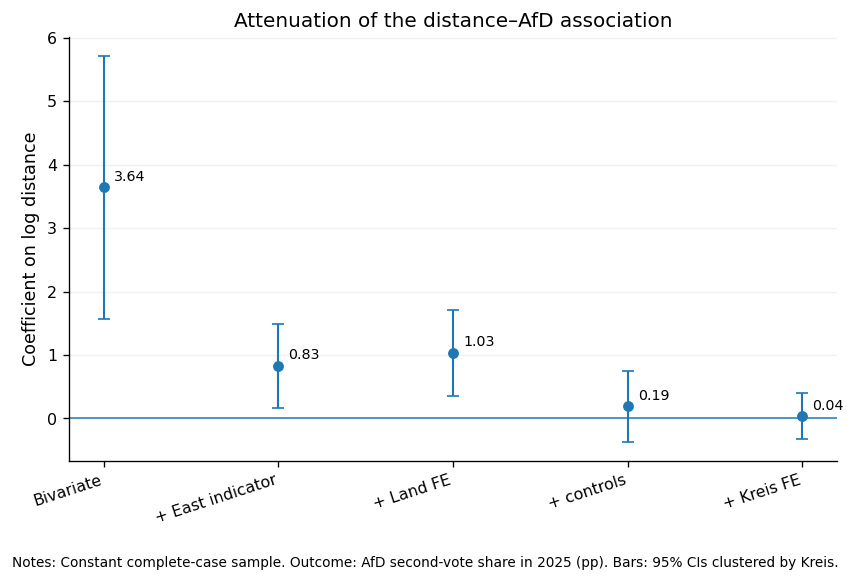

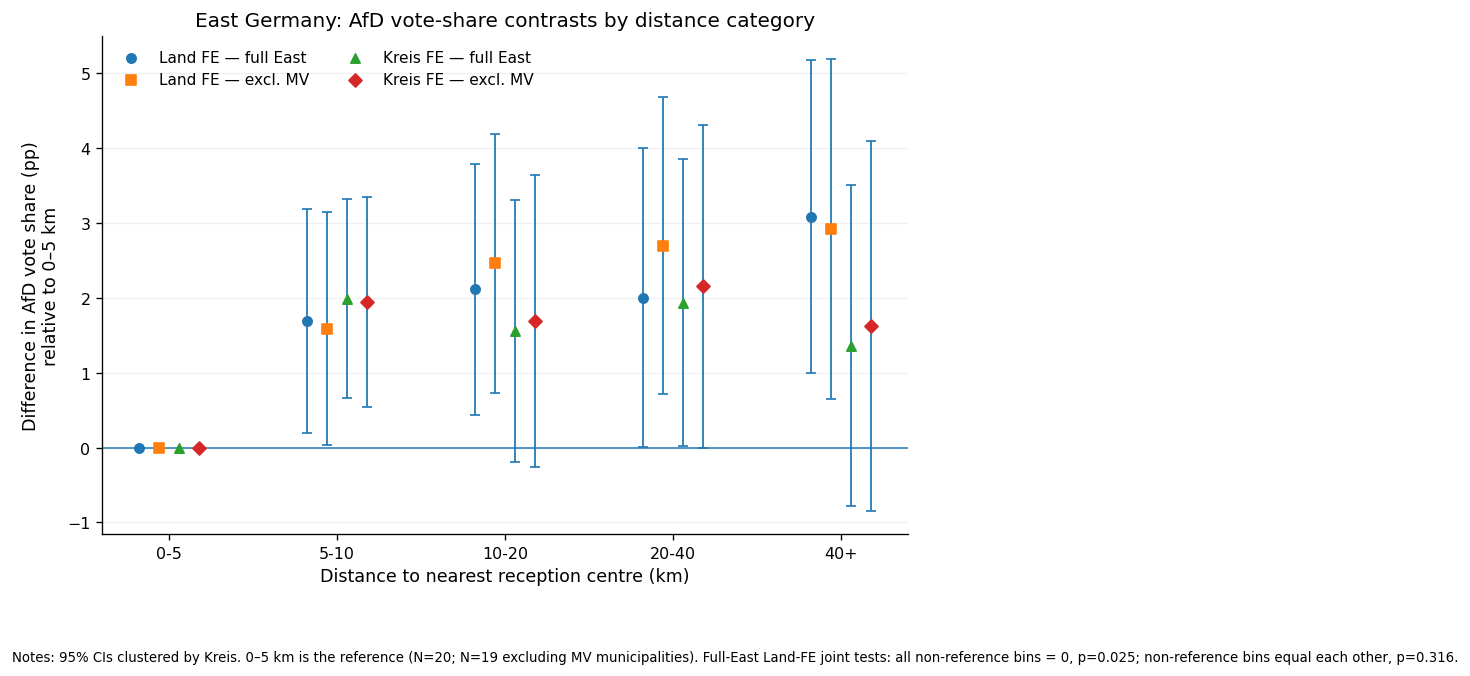

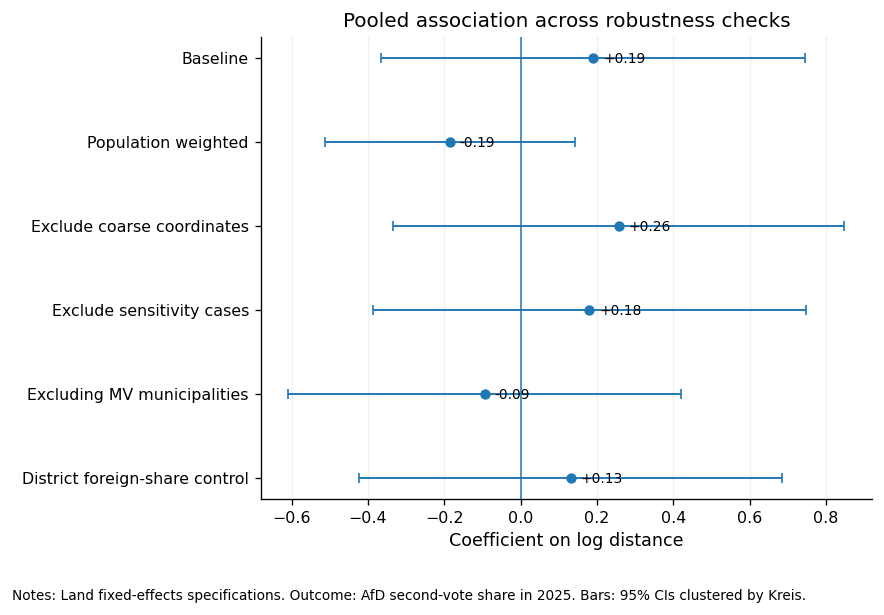

Figures saved to /Users/anastasiacherkashova/Desktop/все здесь/нирс/outputs/figures


In [23]:
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Figure 1
d = ladder_table.copy()
d["low"] = d["beta"] - 1.96*d["SE_Kreis"]
d["high"] = d["beta"] + 1.96*d["SE_Kreis"]

fig, ax = plt.subplots(figsize=(7.2, 4.6))
x = np.arange(len(d))
ax.errorbar(
    x, d["beta"],
    yerr=[d["beta"]-d["low"], d["high"]-d["beta"]],
    fmt="o", markersize=5.5, capsize=3.5, linewidth=1.25
)
ax.axhline(0, linewidth=.9)
ax.set_xticks(x)
ax.set_xticklabels(
    ["Bivariate", "+ East indicator", "+ Land FE", "+ controls", "+ Kreis FE"],
    rotation=18, ha="right"
)
ax.set_ylabel("Coefficient on log distance")
ax.set_title("Attenuation of the distance–AfD association")
ax.yaxis.set_major_locator(MultipleLocator(1))
ax.grid(axis="y", alpha=.18)
for xi, b in zip(x, d["beta"]):
    ax.annotate(f"{b:.2f}", (xi,b), xytext=(6,4), textcoords="offset points", fontsize=8.5)
fig.text(
    .01, -.02,
    "Notes: Constant complete-case sample. Outcome: AfD second-vote share in 2025 (pp). "
    "Bars: 95% CIs clustered by Kreis.",
    ha="left", va="top", fontsize=8.2
)
fig.tight_layout()
save_figure(fig, "figure1_specification_ladder")
plt.show()

# Figure 2
order = ["0-5","5-10","10-20","20-40","40+"]
x = np.arange(len(order))
specs = [
    ("East","State_code","Land FE — full East",-0.18,"o"),
    ("East excluding MV municipalities","State_code","Land FE — excl. MV",-0.06,"s"),
    ("East","Kreis_code","Kreis FE — full East",0.06,"^"),
    ("East excluding MV municipalities","Kreis_code","Kreis FE — excl. MV",0.18,"D"),
]

fig, ax = plt.subplots(figsize=(7.7,5.1))
for sample, fe, label, offset, marker in specs:
    z = bins_table[(bins_table["sample"]==sample) & (bins_table["FE"]==fe)].copy()
    z["bin"] = pd.Categorical(z["bin"], categories=order, ordered=True)
    z = z.sort_values("bin")
    nonref = z["bin"].astype(str)!="0-5"
    xx = x + offset
    ax.scatter(xx, z["beta"], marker=marker, s=31, label=label, zorder=3)
    ax.errorbar(
        xx[nonref], z.loc[nonref,"beta"],
        yerr=1.96*z.loc[nonref,"SE_Kreis"],
        fmt="none", capsize=2.8, linewidth=1.05, zorder=2
    )
ax.axhline(0, linewidth=.9)
ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_xlabel("Distance to nearest reception centre (km)")
ax.set_ylabel("Difference in AfD vote share (pp)\nrelative to 0–5 km")
ax.set_title("East Germany: AfD vote-share contrasts by distance category")
ax.grid(axis="y", alpha=.18)
ax.legend(frameon=False, ncol=2, loc="upper left")

jt_e = joint_tests[joint_tests["sample"]=="East"]
p_zero = float(jt_e.loc[jt_e["test"]=="All non-reference bins = 0","p"].iloc[0])
p_equal = float(jt_e.loc[jt_e["test"]=="Non-reference bins equal each other","p"].iloc[0])
n_ref = int(bins_table.query("sample=='East' and FE=='State_code' and bin=='0-5'")["N_bin"].iloc[0])
n_ref_nomv = int(bins_table.query(
    "sample=='East excluding MV municipalities' and FE=='State_code' and bin=='0-5'"
)["N_bin"].iloc[0])

fig.text(
    .01, -.075,
    f"Notes: 95% CIs clustered by Kreis. 0–5 km is the reference "
    f"(N={n_ref}; N={n_ref_nomv} excluding MV municipalities). "
    f"Full-East Land-FE joint tests: all non-reference bins = 0, p={p_zero:.3f}; "
    f"non-reference bins equal each other, p={p_equal:.3f}.",
    ha="left", va="top", fontsize=8.0
)
fig.tight_layout()
save_figure(fig, "figure2_east_distance_bins")
plt.show()

# Figure 3
wanted = [
    ("Baseline | Land FE","Baseline"),
    ("Population weighted | Land FE","Population weighted"),
    ("Exclude coarse coordinates | Land FE","Exclude coarse coordinates"),
    ("Exclude sensitivity cases | Land FE","Exclude sensitivity cases"),
    ("Excluding MV municipalities | Land FE","Excluding MV municipalities"),
    ("District foreign-share control | Land FE","District foreign-share control"),
]
parts=[]
for model,label in wanted:
    z=robustness_table[robustness_table["model"]==model].copy()
    if len(z):
        z["plot_label"]=label
        parts.append(z)
rp=pd.concat(parts,ignore_index=True)
rp["low"]=rp["beta"]-1.96*rp["SE_Kreis"]
rp["high"]=rp["beta"]+1.96*rp["SE_Kreis"]

fig,ax=plt.subplots(figsize=(7.4,4.8))
y=np.arange(len(rp))
ax.errorbar(
    rp["beta"],y,
    xerr=[rp["beta"]-rp["low"],rp["high"]-rp["beta"]],
    fmt="o",markersize=5.2,capsize=3.2,linewidth=1.15
)
ax.axvline(0,linewidth=.9)
ax.set_yticks(y); ax.set_yticklabels(rp["plot_label"]); ax.invert_yaxis()
ax.set_xlabel("Coefficient on log distance")
ax.set_title("Pooled association across robustness checks")
ax.grid(axis="x",alpha=.18)
for yi,b in zip(y,rp["beta"]):
    ax.annotate(f"{b:+.2f}",(b,yi),xytext=(6,-3),textcoords="offset points",fontsize=8.3)
fig.text(
    .01,-.035,
    "Notes: Land fixed-effects specifications. Outcome: AfD second-vote share in 2025. "
    "Bars: 95% CIs clustered by Kreis.",
    ha="left",va="top",fontsize=8.2
)
fig.tight_layout()
save_figure(fig,"figure3_robustness")
plt.show()

print(f"Figures saved to {FIG.resolve()}")

## 11. Final automated audit checks

These checks are not additional statistical tests. They are guardrails against accidentally changing the input file, mixing samples, reintroducing host municipalities, or regenerating the previously incorrect bootstrap output.

In [41]:
checks = []

def check(name, condition, detail=""):
    checks.append({"check": name, "passed": bool(condition), "detail": detail})
    if not condition:
        raise AssertionError(f"{name} FAILED. {detail}")

check("Non-host sample", n_hosts == 0, f"hosts={n_hosts}")
check("Baseline N", len(baseline) == 10070, f"N={len(baseline)}")
check("Constant N in ladder", ladder_table["N"].nunique() == 1, str(ladder_table["N"].tolist()))
check("Ladder N = baseline N", int(ladder_table["N"].iloc[0]) == len(baseline))
check("Old foreign-share robustness uses baseline N",
      int(robustness_table.loc[
          robustness_table["model"]=="District foreign-share control | Land FE","N"
      ].iloc[0]) == len(baseline))

# Audited point-estimate checkpoints (loose tolerance protects against accidental specification drift).
expected_ladder = np.array([3.641, 0.832, 1.031, 0.191, 0.036])
check(
    "Audited ladder coefficients",
    np.allclose(ladder_table["beta"].to_numpy(), expected_ladder, atol=0.01),
    f"got={ladder_table['beta'].round(3).tolist()}"
)

east_state_beta = float(regional_table.query(
    "sample=='East' and model=='Land FE + controls'"
)["beta"].iloc[0])
east_kreis_beta = float(regional_table.query(
    "sample=='East' and model=='Kreis FE + controls'"
)["beta"].iloc[0])
check("Audited East Land-FE beta", abs(east_state_beta - 1.364) < 0.01, f"beta={east_state_beta:.4f}")
check("Audited East Kreis-FE beta", abs(east_kreis_beta - 0.007) < 0.01, f"beta={east_kreis_beta:.4f}")

if FULL_REPRODUCTION:
    # Leave-one-out must contain exactly one row for every cluster
    # that actually appears in the East estimation sample.
    expected_loo_rows = (
        east_est["nearest_shelter_id"].nunique()
        + east_est["Kreis_code"].nunique()
    )

    check(
        "LOO has one row per estimation-sample cluster",
        len(leave_one_table) == expected_loo_rows,
        (
            f"rows={len(leave_one_table)}, "
            f"expected={expected_loo_rows} "
            f"(shelter={east_est['nearest_shelter_id'].nunique()}, "
            f"Kreis={east_est['Kreis_code'].nunique()})"
        )
    )

    check(
        "LOO drops at least one estimation observation",
        (leave_one_table["N_dropped"] > 0).all(),
        f"min N_dropped={leave_one_table['N_dropped'].min()}"
    )

if FULL_REPRODUCTION:
    check("Bootstrap has six rows", len(bootstrap_table) == 6, f"rows={len(bootstrap_table)}")
   

audit_checks = pd.DataFrame(checks)
audit_checks.to_csv(OUT / "99_reproducibility_checks.csv", index=False)
display(audit_checks)

# Inventory of the exact artifacts produced by this run.
inventory = sorted(str(p.relative_to(OUT)) for p in OUT.rglob("*") if p.is_file())
pd.DataFrame({"artifact": inventory}).to_csv(OUT / "99_output_inventory.csv", index=False)

print("\nREPRODUCIBILITY RUN COMPLETED SUCCESSFULLY.")


,check,passed,detail
0,Non-host sample,True,hosts=0
1,Baseline N,True,N=10070
2,Constant N in ladder,True,"[10070, 10070, 10070, 10070, 10070]"
3,Ladder N = baseline N,True,
4,Old foreign-share robustness uses baseline N,True,
5,Audited ladder coefficients,True,"got=[3.641, 0.832, 1.031, 0.191, 0.036]"
6,Audited East Land-FE beta,True,beta=1.3637
7,Audited East Kreis-FE beta,True,beta=0.0072
8,LOO has one row per estimation-sample cluster,True,"rows=107, expected=107 (shelter=39, Kreis=68)"
9,LOO drops at least one estimation observation,True,min N_dropped=1



REPRODUCIBILITY RUN COMPLETED SUCCESSFULLY.
Output directory: /Users/anastasiacherkashova/Desktop/все здесь/нирс/outputs


## Methodological notes

- The main controlled sample is a complete-case sample of 10,070 non-host municipalities.
- “East” comprises the five eastern Länder represented in the non-host dataset; Berlin is absent because it is itself a host municipality.
- The 0–5 km reference category in the East bin model is small and should be reported explicitly.
- The bin results are **contrasts against a near-centre reference group**, not evidence of a monotonic distance gradient unless the equality test across non-reference bins is rejected.
- Several controls are strongly collinear; their individual coefficients are not interpreted.
- Some Census controls are measured in 2022 and may be post-treatment with respect to earlier centre placement; they are treated as conditioning variables, not causal mediators whose coefficients are interpreted.
- Kreis-FE models contain singleton Kreise and many fixed-effect parameters relative to the number of clusters; inference is therefore reported cautiously, while the collapse of the point estimate is used primarily as evidence about geographic scale.